# Webinar — Regresión con Machine Learning
**TripleTen · Comparando modelos de regresión**

---
## Antes de arrancar

> *Una empresa inmobiliaria entrena un modelo para predecir el precio de casas. En pruebas: R² de 0.95. Lo despliegan. En producción el modelo predice $80,000 para una mansión de $500,000.*

**¿Qué crees que salió mal? Escribe en el chat.**

---

## Agenda

| # | Bloque |
|---|--------|
| 1 | Dataset y exploración |
| 2 | Métricas de regresión: RMSE, MAE, R² |
| 3 | Pipeline + Cross Validation |
| 4 | Comparar 3 modelos |
| 5 | GridSearch |
| 6 | Feature Importances |
| 7 | Modelo final |

**Al terminar vas a poder:**
- Entender cuándo usar RMSE vs MAE vs R²
- Detectar data leakage antes de entrenar
- Construir un pipeline completo de preprocesamiento + modelo
- Comparar LinearRegression, DecisionTree y RandomForest visualmente
- Identificar qué features impulsan el precio de una propiedad

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Los 3 modelos que vamos a comparar
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing

np.random.seed(42)
print('✅ Librerías cargadas')

✅ Librerías cargadas


---
# PARTE 1 — Dataset y exploración

Usamos **California Housing** — dataset clásico incluido en scikit-learn.  
El objetivo es predecir el **precio mediano de casas** (en cientos de miles de dólares) a partir de características del vecindario.

| Feature | Descripción |
|---------|-------------|
| `MedInc` | Ingreso mediano del vecindario |
| `HouseAge` | Antigüedad mediana de las casas |
| `AveRooms` | Promedio de habitaciones por hogar |
| `AveBedrms` | Promedio de dormitorios por hogar |
| `Population` | Población del bloque |
| `AveOccup` | Promedio de ocupantes por hogar |
| `Latitude` | Latitud |
| `Longitude` | Longitud |
| `MedHouseVal` | **Target**: valor mediano de la casa |


In [8]:
# Cargar dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


MedHouseVal         1.000000
sqrt_MedHouseVal    0.988125
MedInc              0.688075
AveRooms            0.151948
HouseAge            0.105623
AveOccup           -0.023737
Population         -0.024650
Longitude          -0.045967
AveBedrms          -0.046701
Latitude           -0.144160
Name: MedHouseVal, dtype: float64


<Axes: >

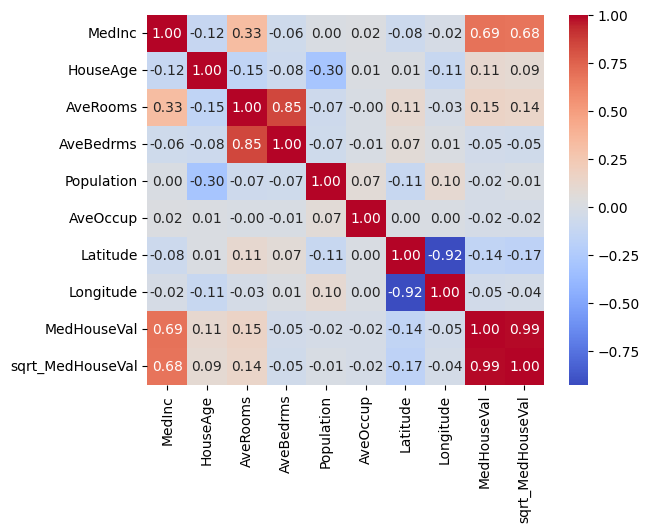

In [16]:
# Distribución del target y correlaciones

# Distribución de variable numérica
plt.hist(np.sqrt(df['MedHouseVal']), bins=30, edgecolor='k')

df["sqrt_MedHouseVal"] = np.sqrt(df["MedHouseVal"])

# Correlación de features con el target
correlations = df.corr()['MedHouseVal'].sort_values(ascending=False)
print(correlations)

# Correlación entre features
cor_matrix = df.corr()


sns.heatmap(cor_matrix, annot=True, fmt=".2f", cmap='coolwarm')


---
# PARTE 2 — Data leakage en regresión

En regresión el data leakage es más silencioso que en clasificación — el modelo sigue funcionando, pero con métricas irreales.

**Ejemplo típico en precios de casas:**
- `precio_por_m2` = `precio_final / metros_cuadrados` → usa el target para calcular la feature ❌
- `valuacion_fiscal_actualizada` → se calcula después de la venta ❌
- `historial_de_ventas_reciente` → no existe al momento de predecir ❌

**Regla de oro:** antes de meter una columna al modelo, preguntá —  
*¿Esta información estaría disponible en el momento real de la predicción?*


---
# PARTE 3 — Métricas de regresión

A diferencia de clasificación (accuracy, f1), en regresión medimos **qué tan lejos** está la predicción del valor real.

| Métrica | Fórmula | Interpretación | Sensible a outliers |
|---------|---------|----------------|---------------------|
| **MAE** | media(\|real - pred\|) | Error promedio en la misma unidad del target | No mucho |
| **RMSE** | √media((real - pred)²) | Penaliza más los errores grandes | Sí, bastante |
| **R²** | 1 - SS_res/SS_tot | % de varianza explicada. 1.0 = perfecto, 0 = trivial | No tanto |

**¿Cuándo usar cada una?**
- Si los errores grandes son muy costosos (medicina, finanzas) → **RMSE**
- Si todos los errores pesan igual → **MAE**
- Para comparar modelos en términos relativos → **R²**

In [ ]:
# Función helper que usaremos en toda la clase
def evaluar_modelo(nombre, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{nombre:<25} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}')
    return {'modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

---
# PARTE 4 — Pipeline + Cross Validation

### ¿Por qué Pipeline?
1. Evita data leakage en el preprocesamiento (el scaler aprende solo del train)
2. Reproducible: un solo objeto para entrenar, evaluar y predecir
3. Compatible con GridSearchCV directamente

### ¿Por qué Cross Validation?
Un solo split train/test puede darte suerte (o mala suerte). CV te da **K evaluaciones independientes** y con eso una estimación del rendimiento real del modelo con su varianza.

In [20]:
# Dividir en train/test
X = df.drop(columns=['MedHouseVal', 'sqrt_MedHouseVal', 'Longitude','AveBedrms'])
y = df['sqrt_MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Column transformer para preprocesamiento


preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), X.columns.tolist())
])


# Crea los pipelines para cada modelo

pipeline_lr = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

pipeline_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

pipeline_dt = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

pipeline_rf


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

---
# PARTE 5 — Comparar los 3 modelos

Ahora sí el bloque central. Vamos a poner a competir:

| Modelo | Tipo | Strengths | Weaknesses |
|--------|------|-----------|------------|
| **LinearRegression** | Lineal | Rápido, interpretable, estable | No captura relaciones no lineales |
| **DecisionTreeRegressor** | No lineal | Captura no linealidades, interpretable | Overfitting fácil sin límite de profundidad |
| **RandomForestRegressor** | Ensemble | Robusto, reduce overfitting, muy preciso | Lento en predicción, menos interpretable |

**Hipótesis:** el precio de una casa NO es lineal respecto al ingreso — esperamos que los árboles superen a LinearRegression.

In [38]:
# Cross Validation con R² (5 folds) para cada modelo
cv_lr = cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring='r2')
cv_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring='r2')  
cv_dt = cross_val_score(pipeline_dt, X_train, y_train, cv=5, scoring='r2')       

In [39]:
# imprimir los resultados de los cross_validation

print(f'Linear Regression CV R²: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')   
print(f'Random Forest CV R²: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')     
print(f'Decision Tree CV R²: {cv_dt.mean():.4f} ± {cv_dt.std():.4f}')     


Linear Regression CV R²: 0.5142 ± 0.0088
Random Forest CV R²: 0.7366 ± 0.0044
Decision Tree CV R²: 0.4720 ± 0.0170


---
# PARTE 6 — GridSearch

RandomForest ganó, pero estamos usando hiperparámetros por defecto.  
GridSearch busca sistemáticamente la mejor combinación.

**Hiperparámetros clave de RandomForest:**
- `n_estimators` — cantidad de árboles. Más árboles = más estable pero más lento
- `max_depth` — profundidad de cada árbol. Controla el overfitting
- `min_samples_split` — mínimo de muestras para hacer un split

In [40]:
# Grid de hiperparámetros (prefijo 'model__' para referencias dentro del pipeline)
param_grid = {
    'model__n_estimators':    [100, 200],
    'model__max_depth':       [10, 20],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('\n✅ GridSearch terminado')
print(f'Mejores parámetros: {grid_search.best_params_}')
print(f'Mejor R² en CV:     {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ GridSearch terminado
Mejores parámetros: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Mejor R² en CV:     0.7377


In [41]:
# Ver todos los resultados del grid ordenados
cv_results = pd.DataFrame(grid_search.cv_results_)
cols = [c for c in cv_results.columns if 'param_' in c] + ['mean_test_score', 'std_test_score', 'rank_test_score']
cv_results[cols].sort_values('rank_test_score').head(8)

,param_model__max_depth,param_model__min_samples_split,param_model__n_estimators,mean_test_score,std_test_score,rank_test_score
7,20,5,200,0.737650,0.004300,1
5,20,2,200,0.737191,0.004360,2
6,20,5,100,0.737078,0.004309,3
4,20,2,100,0.736431,0.004254,4
3,10,5,200,0.726963,0.003583,5
1,10,2,200,0.726887,0.003626,6
2,10,5,100,0.726878,0.003376,7
0,10,2,100,0.726734,0.003451,8


In [51]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [59]:
y_pred = best_model.predict(X_test)
r2_score(y_test, y_pred)

0.730659732003991

---
# PARTE 7 — Feature Importances

¿Qué le importa al modelo para predecir el precio?

**Recordatorio de cómo funciona en RandomForest:**  
Cada vez que un árbol hace un split usando una feature, mide cuánto redujo el MSE esa división.  
La importancia = suma acumulada de esas reducciones, promediada entre todos los árboles.  
Las importancias suman 1.0.

**Limitación:** tiene sesgo hacia features con muchos valores únicos (variables continuas).  
Por eso también veremos **Permutation Importance** como alternativa más robusta.

Population    0.048788
HouseAge      0.064696
AveRooms      0.076710
Latitude      0.110034
AveOccup      0.144818
MedInc        0.554955
dtype: float64


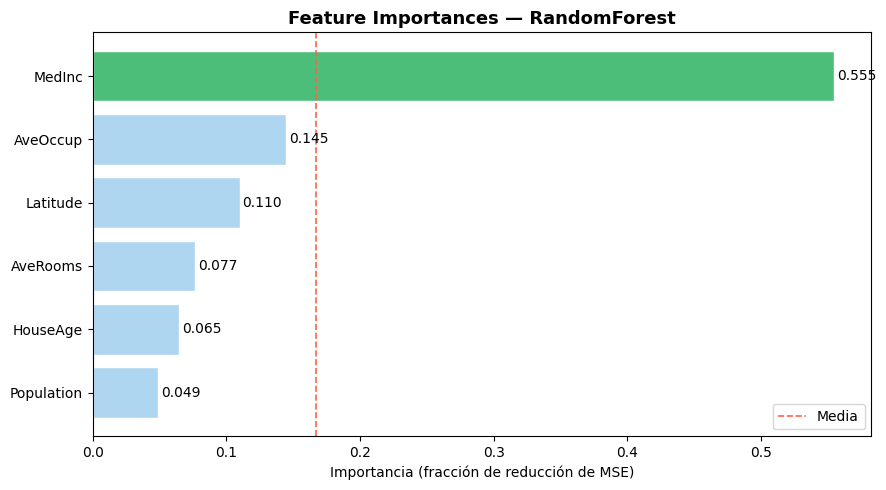


💡 Features por encima de la media (verde) son las más valiosas para el modelo.
   Top feature: MedInc (0.555)
   Coincide con la correlación más alta que vimos en la exploración? ✅


In [42]:
best_model = grid_search.best_estimator_

# Extraer importancias del RandomForest dentro del pipeline
rf_model = best_model.named_steps['model']
feature_names = X.columns.tolist() 

importancias = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=True)


print(importancias)



# Plot
fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['#4CBE7A' if v > importancias.mean() else '#AED6F1' for v in importancias]
bars = ax.barh(importancias.index, importancias.values, color=colors_imp, edgecolor='white')
ax.axvline(importancias.mean(), color='tomato', linestyle='--', linewidth=1.2, label='Media')
ax.set_title('Feature Importances — RandomForest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (fracción de reducción de MSE)')
ax.legend()

for bar, val in zip(bars, importancias.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\n💡 Features por encima de la media (verde) son las más valiosas para el modelo.')
print(f'   Top feature: {importancias.idxmax()} ({importancias.max():.3f})')
print(f'   Coincide con la correlación más alta que vimos en la exploración? ✅')

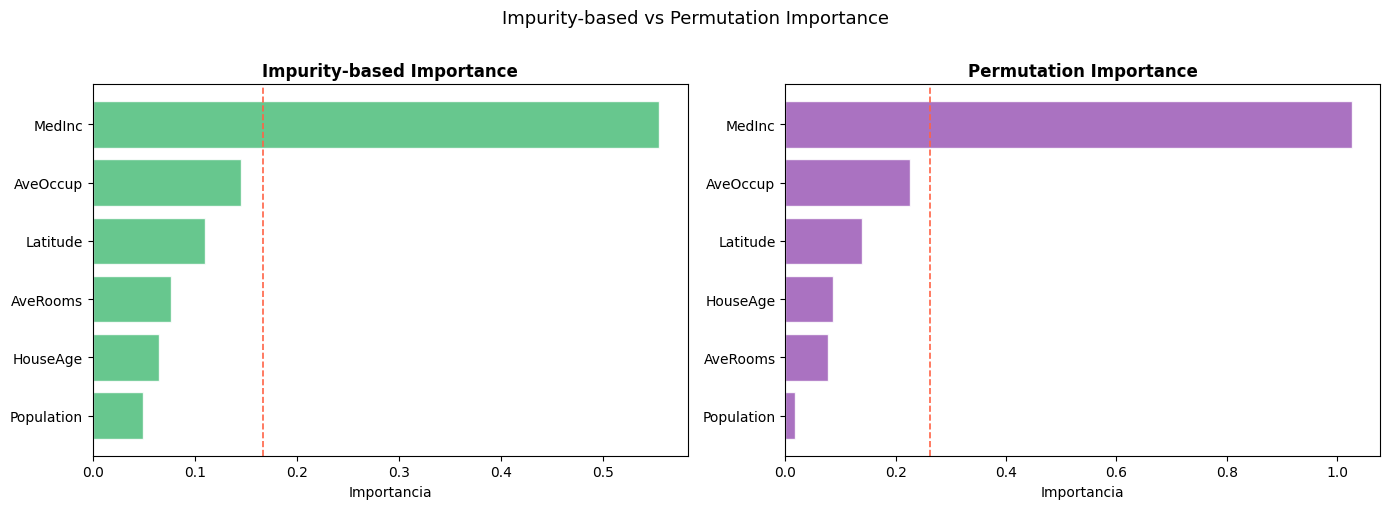

💡 Si el ranking coincide entre ambos métodos → más confianza en la importancia.
   Si difieren mucho → posible sesgo de cardinalidad en impurity-based.


In [43]:
# Permutation Importance — más robusta, no tiene sesgo de cardinalidad
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_series = pd.Series(
    perm_imp.importances_mean,
    index=feature_names
).sort_values(ascending=True)

# Comparación lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, titulo, color in zip(
    axes,
    [importancias, perm_series],
    ['Impurity-based Importance', 'Permutation Importance'],
    ['#4CBE7A', '#9B59B6']
):
    ax.barh(data.index, data.values, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(data.mean(), color='tomato', linestyle='--', linewidth=1.2)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importancia')

plt.suptitle('Impurity-based vs Permutation Importance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('💡 Si el ranking coincide entre ambos métodos → más confianza en la importancia.')
print('   Si difieren mucho → posible sesgo de cardinalidad en impurity-based.')

---
# PARTE 8 — Modelo Final

Con los mejores hiperparámetros encontrados por GridSearch, entrenamos el modelo final  
sobre **todo el dataset de entrenamiento** y lo evaluamos sobre el test set que nunca tocamos.

In [ ]:
pipeline_final_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=grid_search.best_params_['model__n_estimators'],
        max_depth=grid_search.best_params_['model__max_depth'],
        min_samples_split=grid_search.best_params_['model__min_samples_split'],
        random_state=42
    ))
])

pipeline_final_rf.fit(X_train, y_train)


# Evaluación final sobre train set
y_pred_train = pipeline_final_rf.predict(X_train)
mae_final  = mean_absolute_error(y_train, y_pred_train)
rmse_final = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_final   = r2_score(y_train, y_pred_train)
print('=' * 50)
print('  EVALUACIÓN FINAL — Train Set')
print('=' * 50)
print(f'  MAE:  {mae_final:.4f}  (~${mae_final*100_000:,.0f} USD de error promedio)')
print(f'  RMSE: {rmse_final:.4f}  (~${rmse_final*100_000:,.0f} USD)')
print(f'  R²:   {r2_final:.4f}  (explica el {r2_final*100:.1f}% de la varianza del precio)')
print('=' * 50)



# Evaluación final sobre test set
y_pred_final = pipeline_final_rf.predict(X_test)
mae_final  = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final   = r2_score(y_test, y_pred_final)

print('=' * 50)
print('  EVALUACIÓN FINAL — Test Set')
print('=' * 50)
print(f'  MAE:  {mae_final:.4f}  (~${mae_final*100_000:,.0f} USD de error promedio)')
print(f'  RMSE: {rmse_final:.4f}  (~${rmse_final*100_000:,.0f} USD)')
print(f'  R²:   {r2_final:.4f}  (explica el {r2_final*100:.1f}% de la varianza del precio)')
print('=' * 50)

  EVALUACIÓN FINAL — Test Set
  MAE:  0.0640  (~$6,403 USD de error promedio)
  RMSE: 0.0897  (~$8,974 USD)
  R²:   0.9466  (explica el 94.7% de la varianza del precio)
  EVALUACIÓN FINAL — Test Set
  MAE:  0.1427  (~$14,266 USD de error promedio)
  RMSE: 0.2004  (~$20,040 USD)
  R²:   0.7307  (explica el 73.1% de la varianza del precio)


In [ ]:
# Residual plot — detecta sesgos sistemáticos del modelo
residuales = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pred vs Real
axes[0].scatter(y_test, y_pred_final, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title('Real vs Predicho', fontsize=12, fontweight='bold')
axes[0].legend()

# Residuales vs Predicho
axes[1].scatter(y_pred_final, residuales, alpha=0.3, s=10, color='steelblue')
axes[1].axhline(0, color='tomato', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Valor predicho')
axes[1].set_ylabel('Residual (real - predicho)')
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')

plt.suptitle('Diagnóstico del modelo final', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('💡 Un buen modelo tiene residuales centrados en 0, sin patrones visibles.')
print('   Si ves una "V" o una curva → el modelo tiene sesgo sistemático.')
print('   Si ves que los residuales crecen con el valor predicho → heteroscedasticidad.')

---
# Resumen

| Paso | Qué hace | Para qué sirve |
|------|----------|----------------|
| **Data leakage** | Detectar features calculadas con el target | Evitar modelos que hacen trampa |
| **Métricas** | MAE, RMSE, R² | Medir el error en unidades reales |
| **Pipeline** | Encadenar preprocesamiento + modelo | Reproducible y seguro en producción |
| **Cross Validation** | Evaluar con K folds + barras de error | Saber si el modelo es estable |
| **Comparación** | LinearReg vs DecisionTree vs RandomForest | Elegir el enfoque correcto para el problema |
| **GridSearch** | Buscar mejores hiperparámetros | Afinar sin perder generalización |
| **Feature Importances** | Qué columnas aportan más | Explicabilidad + detección de ruido |
| **Residual Plot** | Diagnosticar el modelo final | Detectar sesgos sistemáticos |

---
### Volvamos al caso del inicio

> El modelo pasó de R² 0.95 en pruebas a predecir $80,000 para una mansión de $500,000.

La columna `precio_estimado_agencia` era una transformación ruidosa del target mismo — el modelo aprendió a usarla como atajo. En producción esa columna no existe, y el modelo colapsa.

**Regla:** antes de meter una columna al modelo, preguntá —  
*¿Esta información estaría disponible en el momento real de la predicción?*